In [22]:
import gc
import json
import Grammar
import textacy
import functools
import pandas as pd
import spacy
import ahocorasick
from pathlib import Path
from spacy.tokens import Span
from taxonerd import TaxoNERD
import Entity
from tqdm.auto import tqdm
from typing import List, Any
# import cProfile, pstats, io
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from typing import Dict, Set

In [2]:
df = pd.read_excel("../papers/benchmarks/Benchmark-03-09.xlsx")
df = df[(df['Score'] == 0) | (df['Score'] == 1) | (df['Score'] == 3)]
df.reset_index(inplace=True)
texts = df.Abstract.tolist()
number_texts = len(texts)

In [3]:
# True Papers
df_T = df[df['Score'] == 3]
texts_T = df_T.Abstract.tolist()
number_texts_T = len(texts_T)

In [4]:
# False Papers
df_F = df[(df['Score'] < 3) & (df['Score'] >= 0)]
texts_F = df_F.Abstract.tolist()
number_texts_F = len(texts_F)

In [5]:
def satisfies_ent_req(doc: Entity.ExtendedDoc, ent_instances: List[Span], ents: List[Entity.Entity], verbose=False) -> bool:
    if verbose:
        print('Ents')
        for ent in ent_instances:
            print(ent)
        print()
        print()
    
    # Calculate Counts of Groups
    counts = {}
    for ent in ent_instances:
        ent_text = doc.text_lower[ent.start_char:ent.end_char]
        counts[ent_text] = counts.get(ent_text, 0) + 1
    
    if verbose:
        print('Counts')
        for k, v in counts.items():
            print(v, k)
        print()
        print()
    
    if verbose:
        print('Group\'s Lowers')
        for ent in ents:
            print(ent['lowers'])
        print()
        print()

    # Calculate Counts for Lowers
    lowers: Any = {}
    for ent in ents:
        for lower in ent['lowers']:
            lowers[lower] = lowers.get(lower, 0) +  1

    if verbose:
        print('Lowers')
        for k, v in lowers.items():
            print(v, k)
        print()
        print()

    # Calculate Counts for Entities
    for ent in ents:
        ent['count'] = sum([counts[lower] for lower in ent['lowers']]) # type: ignore
        if verbose:
            print(ent['lowers'], ent['count']) # type: ignore
    if verbose:
        print()
        print()

    non_role_labels = {'v', 's', 'm'}
    non_role_ents = list(ent for ent in ents if non_role_labels & ent['labels'])

    cond_length = len(non_role_ents) >= 2 # Must have >= 2 groups
    cond_counts = len([group for group in non_role_ents if group['count'] >= 2]) >= 2 #type: ignore # Must have at least 2 groups with >= 2 mentions

    flag = cond_length and cond_counts

    if verbose:
        print('Entity Flag:', flag)
        print()
        print()
    
    return flag

In [18]:
# TODO
# Move to names.py?
with open('../data/hard/actions.json') as f:
    words = set(json.load(f))
    actions = ahocorasick.Automaton()
    for word in words:
        actions.add_word(word, word)    
    actions.make_automaton()

with open('../data/hard/interaction.json') as f:
    words = set(json.load(f))
    interactions = ahocorasick.Automaton()
    for word in words:
        interactions.add_word(word, word)    
    interactions.make_automaton()

In [ ]:
def satisfies_int_req(doc: Entity.ExtendedDoc, ent_instances: List[Span], ents: List[Entity.Entity], verbose=False) -> bool:
    mapped_ents = {}
    for j, ent in enumerate(ents):
        if verbose:
            print('Spans', ent['spans'])
            print('Lowers', ent['lowers'])
        for span in ent['spans']:
            if span.text == "crayfish":
                print(span, [token.i for token in span])
            for token in span:
                if token.i not in mapped_ents:
                    mapped_ents[token.i] = set()
                mapped_ents[token.i].add(j)
        if verbose:
            print()
            print()
    
    if verbose:
        print('Mapped Entities')
        print(mapped_ents)
    
    # ------------------------- #
    # METHOD 1: 
    # Look for Species in Triples
    # ------------------------- #
    triples = list(textacy.extract.subject_verb_object_triples(doc.doc)) # type: ignore
    for triple in triples:
        if verbose:
            print('Initial Triple: ', triple)
        
        # This could be done in two lines,
        # but I want to include verbose statements.
        ents_in_sub = set()
        for subject in triple.subject:
            span = Entity.expand_unit(doc.doc, subject.i, subject.i, max(0, subject.i - 7), min(len(doc.doc) - 1, subject.i + 7), speech = ['NOUN', 'PROPN', 'ADJ', 'DET', 'ADP', 'NUM'], literals=[], include=True, direction='BOTH')
            if verbose:
                print('Subject', subject, type(subject), subject.i, doc.doc[subject.i])
                print('Span-Subject', span, type(subject), subject.i)
            if not span:
                continue
            for token in span:
                if verbose:
                    print('\tToken in Span', token, token.i)
                if token.i in mapped_ents:
                    ents_in_sub.update(mapped_ents[token.i])

        ents_in_obj = set()
        for object in triple.object:
            span = Entity.expand_unit(doc.doc, object.i, object.i, max(0, object.i - 7), min(len(doc.doc) - 1, object.i + 7), speech = ['NOUN', 'PROPN', 'ADJ', 'DET', 'ADP', 'NUM'], literals=[], include=True, direction='BOTH')
            if not span:
                continue
            if verbose:
                print('Object', object, type(object), object.i, doc.doc[object.i])
                print('Span Object', span, type(object), object.i)
            for token in span:
                if verbose:
                    print('\tToken in Span', token, token.i)
                if token.i in mapped_ents:
                    ents_in_obj.update(mapped_ents[token.i])
        
        # ents_in_sub = set().union(*[mapped_ents[token.i] for token in set().union(*[{*span} for span in filter_spans([subject for subject in [expand_unit(doc.doc, token.i, token.i, token.i - 5, token.i + 5, speech = ['NOUN', 'PROPN', 'ADJ', 'DET', 'ADP'], literals=[], include=True, direction='BOTH') for token in triple.subject] if subject])]) if token and token.i in mapped_ents])
        # ents_in_obj = set().union(*[mapped_ents[token.i] for token in set().union(*[{*span} for span in filter_spans([object for object in [expand_unit(doc.doc, token.i, token.i, token.i - 5, token.i + 5, speech = ['NOUN', 'PROPN', 'ADJ', 'DET', 'ADP'], literals=[], include=True, direction='BOTH') for token in triple.object] if object])]) if token and token.i in mapped_ents])

        if verbose:
            print('\tEntities of S:', ents_in_sub)
            print('\tEntities of O:', ents_in_obj)

        if ents_in_sub and ents_in_obj and ents_in_sub ^ ents_in_obj:
            if verbose:
                print('Interaction Flag: True\n\n')
            return True
    
    # ------------------------------------------- #
    # METHOD 2: 
    # Look for Interaction + Cause-Change + Species
    # ------------------------------------------- #

    # Interaction (IN) Tokens
    in_tokens = set()
    for r_i, key in interactions.iter(doc.text_lower):
        r_i += 1
        l_i = r_i - len(key)

        if verbose:
            print('\tInteraction Key Found: ', key)
        
        if (
            (l_i != 0 and not Entity.is_boundary(doc.text_lower[l_i-1])) or 
            (r_i != len(doc.text_lower) and not Entity.is_boundary(doc.text_lower[r_i]))
        ):
            continue
        
        if span := doc.doc.char_span(l_i, r_i, alignment_mode='expand'):
            in_tokens.add(span[0])

    if verbose:
        print('Interaction Tokens:', in_tokens)
    
    # Cause and Change (CC) Tokens
    cc_tokens = set()
    for r_i, key in actions.iter(doc.text_lower):
        r_i += 1
        l_i = r_i - len(key)

        if verbose:
            print('\tCause-Change Key Found: ', key)
        
        if (
            (l_i != 0 and not Entity.is_boundary(doc.text_lower[l_i-1])) or 
            (r_i != len(doc.text_lower) and not Entity.is_boundary(doc.text_lower[r_i]))
        ):
            continue
        
        if span := doc.doc.char_span(l_i, r_i, alignment_mode='expand'):
            cc_tokens.add(span[0])
    
    if verbose:
        print('Cause and Change Tokens:', cc_tokens)
    
    # Look for Triples (Interaction, CC, Species)
    ent_tokens = set(mapped_ents.keys())

    if verbose:
        print('Entity Tokens:', ent_tokens)
    
    for in_token in in_tokens:
        if verbose:
            print('Interaction Token:', in_token)
            print('\tInteraction Token Neighbors:', doc.doc[in_token.i-5:in_token.i+5])
            print('\tSentence Tokens:', in_token.sent, list(token.i for token in in_token.sent))

        if not cc_tokens.intersection(doc.doc[in_token.i-5:in_token.i+5]):
            continue
        
        if verbose:
            print('\tEntities in Sentence:', set().union(*[mapped_ents[i] for i in ent_tokens.intersection(token.i for token in in_token.sent)]))
        if len(set().union(*[mapped_ents[i] for i in ent_tokens.intersection(token.i for token in in_token.sent)])) >= 1:
            if verbose:
                print('Interaction Flag: True\n\n')
            return True

    if verbose:
        print('Interaction Flag: False\n\n')
    return False

In [ ]:
# type: ignore
nlp = TaxoNERD(prefer_gpu=True).load(
    model="en_ner_eco_biobert", 
    # exclude=["tok2vec", "parser", "lemmatizer"]
)
spacy.require_gpu()

True

In [ ]:
# Clear Cache
wrappers = [a for a in gc.get_objects() if isinstance(a, functools._lru_cache_wrapper)]
for wrapper in wrappers:
    wrapper.cache_clear()

100%|██████████| 1/1 [00:00<00:00,  2.59it/s]


Text 0
A growing body of research suggests that direct and indirect interactions among consumers can have strong effects on the abundance of their prey. We examined the independent and interactive effects of 2 common freshwater consumers, crayfish (Orconectes propinquus) and rainbow darters (Etheostoma caeruleum), on benthic macroinvertebrates in a southern Michigan, USA, stream. A secondary goal was to assess the effects of crayfish and darters on the basal trophic level (periphyton) in the system. Presence and absence of crayfish and darters were manipulated in situ in wire mesh cages (0.2 m<sup>2</sup>, 6-mm mesh) using a 2 × 2 factorial, randomized block design. Invertebrates and periphyton (for chlorophyll a analysis) were sampled biweekly for 6 wk from artificial rock substrates within these cages. Neither consumer significantly affected chlorophyll a accumulation. Darters alone had no significant effects on total invertebrate abundance. Crayfish alone caused, on average, a 58% 

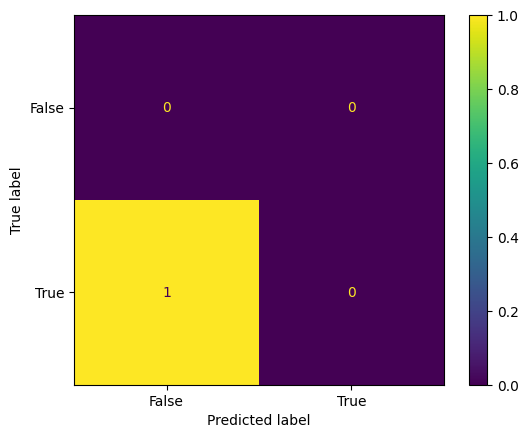

[0]


In [ ]:
txts = [Entity.clean_text(text) for i, text in enumerate(texts_T) if i in [25]]

y_pred = []
y_true = []
bad = []

verbose = True

i = 0
for doc in tqdm(nlp.pipe(txts, batch_size=1), total=len(txts)):
    doc_extended = Entity.ExtendedDoc(doc)

    if verbose:
        print()
        print('Text', i)
        print(doc.text)
        print()
        print()
    
    
    # Find Entity Instances
    find = Entity.FindEntityInstances(doc_extended)
    ent_instances = find(verbose=False)

    # Resolve Entity Instances
    resolve = Entity.ResolveEntityInstances(doc_extended)
    ents = resolve(ent_instances, verbose=False)
    resolve.conn.close()

    # Flag
    flag_ent = satisfies_ent_req(doc_extended, ent_instances, ents, verbose=False)
    flag_int = satisfies_int_req(doc_extended, ent_instances, ents, verbose=True)

    # Put Flags Together
    y_pred.append(flag_ent and flag_int)
    y_true.append(True)

    if y_true[-1] != y_pred[-1]:
        bad.append(i)

    i += 1

ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
plt.show()
print(bad)

In [ ]:
'crayfish' in Entity.vernaculars

In [ ]:
[name for name in Entity.mapped_names['crayfish'] if Entity.in_scientific(name) in {'species', 'scientificName'}]

In [ ]:
[Entity.in_scientific(name) for name in Entity.mapped_names['crayfish']]

In [ ]:
# filename = "4-ScreenByEntities"


# def save(*, mask, counts, errors, suffix):
#     outputs = {
#         "counts": counts,
#         "mask": mask,
#         "errors": errors
#     }
    
#     with open(rf'{filename}-{suffix or 0}.pickle', 'wb') as file:
#         pickle.dump(outputs, file)


# def load(suffix):
#     outputs = {
#         "errors": {},
#         "counts": {
#             None: 0, 
#             True: 0, 
#             False: 0
#         },
#         "mask": []
#     }

#     fn = f'{filename}-{suffix or 0}.pickle'

#     # Nothing To Load
#     if not os.path.isfile(fn):
#         return outputs

#     with open(fn, 'rb') as file:
#         outputs = pickle.load(file)
    
#     return outputs

In [ ]:
# papers = pd.read_csv('3_Papers_Screened.csv')
# texts = papers.Abstract.tolist()
# number_texts = len(texts)

In [ ]:
# # type: ignore
# suffix = None

# outputs = load(suffix)
# mask = outputs['mask']
# counts = outputs['counts']
# errors = outputs['errors']

# i = len(mask)

# progress = tqdm(nlp.pipe(texts, batch_size=128), total=number_texts)
# for doc in progress:
#     progress.set_postfix({
#         'Errors': counts[None], 
#         'Included': counts[True], 
#         'Excluded': counts[False]
#     }, refresh=True)

#     # Auto-Save
#     if (i + 1) % 256:
#         save(
#             mask=mask, 
#             counts=counts, 
#             errors=errors, 
#             suffix=suffix
#         )
    
#     try:
#         flag = False
#     except Exception as e:
#         flag = None
#         errors[i] = e

#     counts[flag] += 1
#     mask.append(flag)
    
#     i += 1